# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [4]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [5]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [6]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [ ]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [21]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

### Ejercicio 1

In [14]:
# --- SOLUCIÓN EJERCICIO 1: Exploración Inicial ---

# 1. Leemos los datos en modo BATCH (foto fija) para poder contarlos.
# Usamos el mismo topic ("sensores") y el mismo 'schema' que ya definió el profesor.
df_exploracion = spark.read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "kafka:9092") \
    .option("subscribe", "sensores") \
    .option("startingOffsets", "earliest") \
    .option("endingOffsets", "latest") \
    .load() \
    .select(from_json(col("value").cast("string"), schema).alias("data")) \
    .select("data.*")

print("=== RESULTADOS EJERCICIO 1 ===")

# Pregunta 1: Muestra el esquema completo
print("\n1. Esquema del DataFrame:")
df_exploracion.printSchema()

# Pregunta 2: Indica cuántas filas contiene
print(f"\n2. Total de filas capturadas: {df_exploracion.count()}")

# Pregunta 3: ¿Cuántos sensores distintos aparecen?
num_sensors = df_exploracion.select("sensor_id").distinct().count()
print(f"\n3. Cantidad de sensores distintos: {num_sensors}")

=== RESULTADOS EJERCICIO 1 ===

1. Esquema del DataFrame:
root
 |-- sensor_id: string (nullable = true)
 |-- value: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- status: string (nullable = true)
 |-- timestamp: double (nullable = true)
 |-- uuid: string (nullable = true)


2. Total de filas capturadas: 1926

3. Cantidad de sensores distintos: 4


### Ejercicio 2

In [15]:
# --- SOLUCIÓN EJERCICIO 2: TRANSFORMACIONES ---
from pyspark.sql.functions import col, min, max, avg

# 1. Creamos una columna nueva
# Calculamos: Diferencia = Temperatura - Humedad
df_transformado = df_exploracion.withColumn("diferencia", col("temperature") - col("humidity"))

print("=== RESPUESTAS EJERCICIO 2 ===")
print("Estadísticas de la nueva columna (Temperatura - Humedad):")

# 2. Calculamos el Mínimo, Máximo y Media de esa nueva columna
df_transformado.select(
    min("diferencia").alias("Minimo"),
    max("diferencia").alias("Maximo"),
    avg("diferencia").alias("Media")
).show()

=== RESPUESTAS EJERCICIO 2 ===
Estadísticas de la nueva columna (Temperatura - Humedad):
+------+------+-----------------+
|Minimo|Maximo|            Media|
+------+------+-----------------+
| -67.2| 69.03|1.699016881827209|
+------+------+-----------------+



### Ejercicio 3

In [16]:
# --- SOLUCIÓN EJERCICIO 3: FILTRADO AVANZADO ---
from pyspark.sql.functions import avg, count, col

# 1. Primero agrupamos por sensor para conseguir el "número de eventos" y la humedad media.
df_agrupado = df_exploracion.groupBy("sensor_id").agg(
    avg("humidity").alias("humedad_media"),
    count("*").alias("num_eventos")
)

# 2. Aplicamos el filtro con las 3 condiciones que pide el ejercicio:
#    - Que la humedad media sea mayor a un valor (ej: 10)
#    - Que el número de eventos sea relevante (ej: al menos 1)
#    - Que el sensor no sea nulo
df_filtrado = df_agrupado.filter(
    (col("humedad_media") > 10) &      # Condición 1: Humedad
    (col("num_eventos") >= 1) &        # Condición 2: Número de eventos
    (col("sensor_id").isNotNull())     # Condición 3: Sensor específico
)

print("=== RESPUESTAS EJERCICIO 3 ===")
print("Tabla con los filtros aplicados:")
df_filtrado.show()

# Respuesta final a la pregunta:
print(f"¿Cuántos registros (sensores) cumplen todas las condiciones?: {df_filtrado.count()}")

=== RESPUESTAS EJERCICIO 3 ===
Tabla con los filtros aplicados:
+---------+------------------+-----------+
|sensor_id|     humedad_media|num_eventos|
+---------+------------------+-----------+
|       S4| 54.73784883720929|        516|
|       S3|53.553749999999965|        544|
|       S2| 54.45611806797859|        559|
|       S1|  54.2875547445256|        548|
+---------+------------------+-----------+

¿Cuántos registros (sensores) cumplen todas las condiciones?: 4


### Ejercicio 4

In [17]:
# --- SOLUCIÓN EJERCICIO 4: AGREGACIONES POR SENSOR ---
from pyspark.sql.functions import avg, max, count, desc

# 1. Agrupamos por 'sensor_id' y calculamos las 3 métricas que piden:
#    - Media de temperatura (variable analizada)
#    - Temperatura máxima
#    - Conteo de registros (grupos/ventanas recibidos)
df_stats_sensor = df_exploracion.groupBy("sensor_id").agg(
    avg("temperature").alias("media_temp"),
    max("temperature").alias("max_temp"),
    count("*").alias("num_registros")
)

print("=== TABLA GENERAL POR SENSOR ===")
df_stats_sensor.show()

print("\n=== RESPUESTAS A LAS PREGUNTAS ===")

# Pregunta 1: ¿Qué sensor tiene la mayor media?
# Ordenamos por media descendente y cogemos el primero
top_media = df_stats_sensor.orderBy(desc("media_temp")).first()
print(f"1. Sensor con mayor media: {top_media['sensor_id']} (Media: {top_media['media_temp']:.2f})")

# Pregunta 2: ¿Qué sensor presenta la temperatura máxima?
# Ordenamos por max_temp descendente
top_max = df_stats_sensor.orderBy(desc("max_temp")).first()
print(f"2. Sensor con temperatura máxima: {top_max['sensor_id']} (Max: {top_max['max_temp']})")

# Pregunta 3: ¿Cuántos grupos o ventanas existen por sensor?
# Esto equivale al número de registros que hemos contado
print("3. Grupos/Registros por sensor:")
df_stats_sensor.select("sensor_id", "num_registros").show()

=== TABLA GENERAL POR SENSOR ===
+---------+-----------------+--------+-------------+
|sensor_id|       media_temp|max_temp|num_registros|
+---------+-----------------+--------+-------------+
|       S4|54.69994525547448|    90.0|          548|
|       S3|55.36495711835334|   89.74|          583|
|       S2|55.45144312393885|   89.98|          589|
|       S1|56.18901023890787|   89.87|          586|
+---------+-----------------+--------+-------------+


=== RESPUESTAS A LAS PREGUNTAS ===
1. Sensor con mayor media: S1 (Media: 56.15)
2. Sensor con temperatura máxima: S4 (Max: 90.0)
3. Grupos/Registros por sensor:
+---------+-------------+
|sensor_id|num_registros|
+---------+-------------+
|       S4|          548|
|       S3|          583|
|       S2|          591|
|       S1|          587|
+---------+-------------+



### Ejercicio 5

In [18]:
# --- SOLUCIÓN EJERCICIO 5: RANKING CON VENTANAS ---
from pyspark.sql.window import Window
from pyspark.sql.functions import window, row_number, desc, col, avg

# 1. PREPARACIÓN: Necesitamos calcular el 'avg_value' primero
# (Replicamos la lógica del profesor pero en modo estático para que funcione el ranking)
df_con_tiempo = df_exploracion.withColumn("event_time", col("timestamp").cast("timestamp"))

df_agregado = df_con_tiempo.groupBy(
    window("event_time", "30 seconds"), 
    "sensor_id"
).agg(
    avg("value").alias("avg_value")
)

# 2. DEFINIR LA VENTANA (WINDOW)
# Queremos hacer un ranking POR sensor, ordenado por el valor medio MÁS ALTO
ventana_spec = Window.partitionBy("sensor_id").orderBy(desc("avg_value"))

# 3. APLICAR EL RANKING
# Creamos una columna 'ranking' que pone un 1 al mejor valor de cada sensor, un 2 al siguiente, etc.
df_rankeado = df_agregado.withColumn("ranking", row_number().over(ventana_spec))

# Filtramos para quedarnos solo con el MEJOR registro de cada sensor (el número 1)
df_mejores_por_sensor = df_rankeado.filter(col("ranking") == 1)

print("=== MEJOR REGISTRO DE CADA SENSOR ===")
df_mejores_por_sensor.select("sensor_id", "avg_value").show()

print("\n=== RESPUESTA: ¿QUIÉN TIENE EL MÁXIMO GLOBAL? ===")
# Ordenamos los mejores de cada sensor para ver quién gana de todos
ganador = df_mejores_por_sensor.orderBy(desc("avg_value")).first()

print(f"El sensor con el valor máximo global es: {ganador['sensor_id']}")
print(f"Con un valor medio de: {ganador['avg_value']}")

=== MEJOR REGISTRO DE CADA SENSOR ===
+---------+-----------------+
|sensor_id|        avg_value|
+---------+-----------------+
|       S1|38.67333333333333|
|       S2|42.75333333333333|
|       S3|            49.49|
|       S4|            42.23|
+---------+-----------------+


=== RESPUESTA: ¿QUIÉN TIENE EL MÁXIMO GLOBAL? ===
El sensor con el valor máximo global es: S3
Con un valor medio de: 49.49


### Ejercicio 6

In [19]:
# --- SOLUCIÓN EJERCICIO 6: JOIN CON TABLA AUXILIAR ---
from pyspark.sql.functions import lit

# 1. CREAR DATAFRAME AUXILIAR
# Para asegurar que el cruce funcione, cogemos los sensores que ya tienes
# y les inventamos una "Ubicación" y un "Modelo".
df_info_extra = df_exploracion.select("sensor_id").distinct() \
    .withColumn("ubicacion", lit("Planta 1 - Sector A")) \
    .withColumn("tipo_sensor", lit("Termohigrómetro V2"))

print("=== TABLA AUXILIAR CREADA ===")
df_info_extra.show(3, truncate=False)

# 2. REALIZAR EL JOIN
# Cruzamos tus datos originales con la nueva tabla usando 'sensor_id'
df_unido = df_exploracion.join(df_info_extra, on="sensor_id", how="inner")

print("\n=== RESULTADO DEL JOIN (Primeros 5 registros) ===")
# El enunciado pide mostrar los cinco primeros registros
df_unido.show(5)

=== TABLA AUXILIAR CREADA ===
+---------+-------------------+------------------+
|sensor_id|ubicacion          |tipo_sensor       |
+---------+-------------------+------------------+
|S4       |Planta 1 - Sector A|Termohigrómetro V2|
|S3       |Planta 1 - Sector A|Termohigrómetro V2|
|S2       |Planta 1 - Sector A|Termohigrómetro V2|
+---------+-------------------+------------------+
only showing top 3 rows


=== RESULTADO DEL JOIN (Primeros 5 registros) ===
+---------+-----+-----------+--------+------+--------------------+--------------------+-------------------+------------------+
|sensor_id|value|temperature|humidity|status|           timestamp|                uuid|          ubicacion|       tipo_sensor|
+---------+-----+-----------+--------+------+--------------------+--------------------+-------------------+------------------+
|       S4|26.67|      60.72|   45.01|  FAIL|1.7658211263094387E9|11a075bd-6e5b-4eb...|Planta 1 - Sector A|Termohigrómetro V2|
|       S4| 35.6|      31.83|

### Ejercicio 7

In [20]:
# --- SOLUCIÓN EJERCICIO 7: AGRUPACIÓN TEMPORAL ---
from pyspark.sql.functions import col, date_trunc, avg, count

# 1. PREPARAR EL TIEMPO
# Nos aseguramos de tener la columna 'event_time' y creamos una nueva columna 
# 'inicio_minuto' que trunca el tiempo al minuto exacto (elimina los segundos).
df_temporal = df_exploracion.withColumn("event_time", col("timestamp").cast("timestamp")) \
                            .withColumn("inicio_minuto", date_trunc("minute", col("event_time")))

# 2. AGRUPAR POR UNIDAD DE TIEMPO (MINUTO)
# Agrupamos por ese minuto para calcular las estadísticas que pide el enunciado.
df_resumen_tiempo = df_temporal.groupBy("inicio_minuto").agg(
    count("*").alias("total_eventos_ventanas"),  # ¿Cuántas ventanas/eventos hay?
    avg("humidity").alias("humedad_media")       # ¿Humedad media?
).orderBy("inicio_minuto")

print("=== RESUMEN POR MINUTO ===")
df_resumen_tiempo.show(truncate=False)

print("\n=== RESPUESTAS ===")
# Extraemos el primer registro para dar un ejemplo en texto
ejemplo = df_resumen_tiempo.first()
if ejemplo:
    print(f"Por ejemplo, en el minuto {ejemplo['inicio_minuto']}:")
    print(f"- Se registraron {ejemplo['total_eventos_ventanas']} eventos/ventanas.")
    print(f"- La humedad media fue de {ejemplo['humedad_media']:.2f}.")

=== RESUMEN POR MINUTO ===
+-------------------+----------------------+------------------+
|inicio_minuto      |total_eventos_ventanas|humedad_media     |
+-------------------+----------------------+------------------+
|2025-12-15 17:52:00|55                    |51.00472727272728 |
|2025-12-15 17:53:00|2                     |27.4              |
|2025-12-16 09:26:00|34                    |57.22029411764705 |
|2025-12-16 09:27:00|60                    |52.53816666666666 |
|2025-12-16 09:28:00|59                    |54.81050847457629 |
|2025-12-16 09:29:00|60                    |55.19316666666669 |
|2025-12-16 09:30:00|60                    |56.03             |
|2025-12-16 09:31:00|60                    |51.061            |
|2025-12-16 09:32:00|60                    |54.385            |
|2025-12-16 09:33:00|60                    |56.20033333333335 |
|2025-12-16 09:34:00|60                    |55.791500000000006|
|2025-12-16 09:35:00|59                    |53.288474576271184|
|2025-12-16 0

### Ejercicio 8

In [21]:
# --- SOLUCIÓN EJERCICIO 8: REPARTICIÓN Y PARTICIONES ---
from pyspark.sql.functions import spark_partition_id, count

# 1. REPARTIR EL DATAFRAME
# Forzamos a Spark a reorganizar los datos en 4 "cajones" (particiones) 
# basándose en el sensor_id. Así, cada sensor debería ir siempre al mismo cajón.
num_particiones = 4
df_repartido = df_exploracion.repartition(num_particiones, "sensor_id")

# 2. AÑADIR IDENTIFICADOR DE PARTICIÓN
# Creamos una columna que nos chiva en qué número de partición está cada fila
df_analisis_particion = df_repartido.withColumn("n_particion", spark_partition_id())

print("=== MUESTRA: SENSOR vs PARTICIÓN ===")
# Mostramos unos cuantos para ver que el mismo sensor siempre tiene el mismo n_particion
df_analisis_particion.select("sensor_id", "n_particion").show(10)

print("\n=== RESPUESTA: DISTRIBUCIÓN DE REGISTROS ===")
# Contamos cuántas filas han caído en cada cajón
df_analisis_particion.groupBy("n_particion").count().show()

=== MUESTRA: SENSOR vs PARTICIÓN ===
+---------+-----------+
|sensor_id|n_particion|
+---------+-----------+
|       S3|          0|
|       S3|          0|
|       S3|          0|
|       S3|          0|
|       S3|          0|
|       S3|          0|
|       S3|          0|
|       S3|          0|
|       S3|          0|
|       S3|          0|
+---------+-----------+
only showing top 10 rows


=== RESPUESTA: DISTRIBUCIÓN DE REGISTROS ===
+-----------+-----+
|n_particion|count|
+-----------+-----+
|          0|  682|
|          1| 1297|
|          3|  682|
+-----------+-----+



### Ejercicio 9

In [22]:
# --- SOLUCIÓN EJERCICIO 9: DETECCIÓN DE ANOMALÍAS ---
from pyspark.sql.functions import avg, col, desc

# 1. CALCULAR LA MEDIA GLOBAL
# Primero necesitamos saber cuál es la temperatura media de todo el dataset
row_media = df_exploracion.agg(avg("temperature").alias("media_global")).collect()[0]
media_temp = row_media["media_global"]

print(f"--- CRITERIO DEFINIDO: Temperatura > Media Global ({media_temp:.2f}) ---")

# 2. FILTRAR ANOMALÍAS
# Seleccionamos solo las filas que cumplen nuestro criterio de anomalía
df_anomalies = df_exploracion.filter(col("temperature") > media_temp)

print("\n=== RESPUESTAS EJERCICIO 9 ===")

# Pregunta 1: ¿Cuántos registros son anómalos?
total_anomalos = df_anomalies.count()
print(f"1. Total de registros considerados anómalos: {total_anomalos}")

# Pregunta 2: ¿Qué sensor tiene más anomalías?
# Agrupamos los datos anómalos por sensor y ordenamos de mayor a menor
top_sensor = df_anomalies.groupBy("sensor_id").count().orderBy(desc("count")).first()

if top_sensor:
    print(f"2. El sensor con más anomalías es: {top_sensor['sensor_id']} (con {top_sensor['count']} registros)")
else:
    print("2. No se encontraron anomalías.")

--- CRITERIO DEFINIDO: Temperatura > Media Global (55.56) ---

=== RESPUESTAS EJERCICIO 9 ===
1. Total de registros considerados anómalos: 1385
2. El sensor con más anomalías es: S1 (con 361 registros)


### Ejercicio 10

In [23]:
# --- SOLUCIÓN EJERCICIO 10: CRUCE DE MÉTRICAS (SCORING) ---
from pyspark.sql.functions import col, desc

# 1. DEFINIR LA FÓRMULA DE PUNTUACIÓN
# Creamos una columna 'score' aplicando unos pesos arbitrarios a cada métrica
df_con_puntuacion = df_exploracion.withColumn(
    "score", 
    (col("temperature") * 0.5) + (col("humidity") * 0.2) + (col("value") * 0.3)
)

print("=== MUESTRA DE PUNTUACIONES CALCULADAS ===")
df_con_puntuacion.select("sensor_id", "temperature", "humidity", "value", "score").show(5)

# 2. ENCONTRAR EL GANADOR
# Ordenamos por la puntuación más alta para ver qué sensor se lleva el premio
ganador = df_con_puntuacion.orderBy(desc("score")).first()

print("\n=== RESPUESTAS EJERCICIO 10 ===")

if ganador:
    print(f"1. El sensor con la puntuación más alta es: {ganador['sensor_id']}")
    print(f"2. El valor de dicha puntuación es: {ganador['score']:.4f}")
    
    print("\nDetalles del registro ganador:")
    print(f"- Temp: {ganador['temperature']}, Hum: {ganador['humidity']}, Val: {ganador['value']}")

=== MUESTRA DE PUNTUACIONES CALCULADAS ===
+---------+-----------+--------+-----+------------------+
|sensor_id|temperature|humidity|value|             score|
+---------+-----------+--------+-----+------------------+
|       S1|      52.54|   84.52|26.74|            51.196|
|       S4|      60.72|   45.01|26.67|            47.363|
|       S1|      24.52|   32.61|18.25|24.256999999999998|
|       S3|      31.87|   80.66|16.74|            37.089|
|       S2|      83.18|   40.76|43.29|62.729000000000006|
+---------+-----------+--------+-----+------------------+
only showing top 5 rows


=== RESPUESTAS EJERCICIO 10 ===
1. El sensor con la puntuación más alta es: S4
2. El valor de dicha puntuación es: 76.4120

Detalles del registro ganador:
- Temp: 87.04, Hum: 89.82, Val: 49.76


### Ejercicio 11

Convirtiendo datos de Spark a Pandas... (esto puede tardar un poco si hay muchos datos)


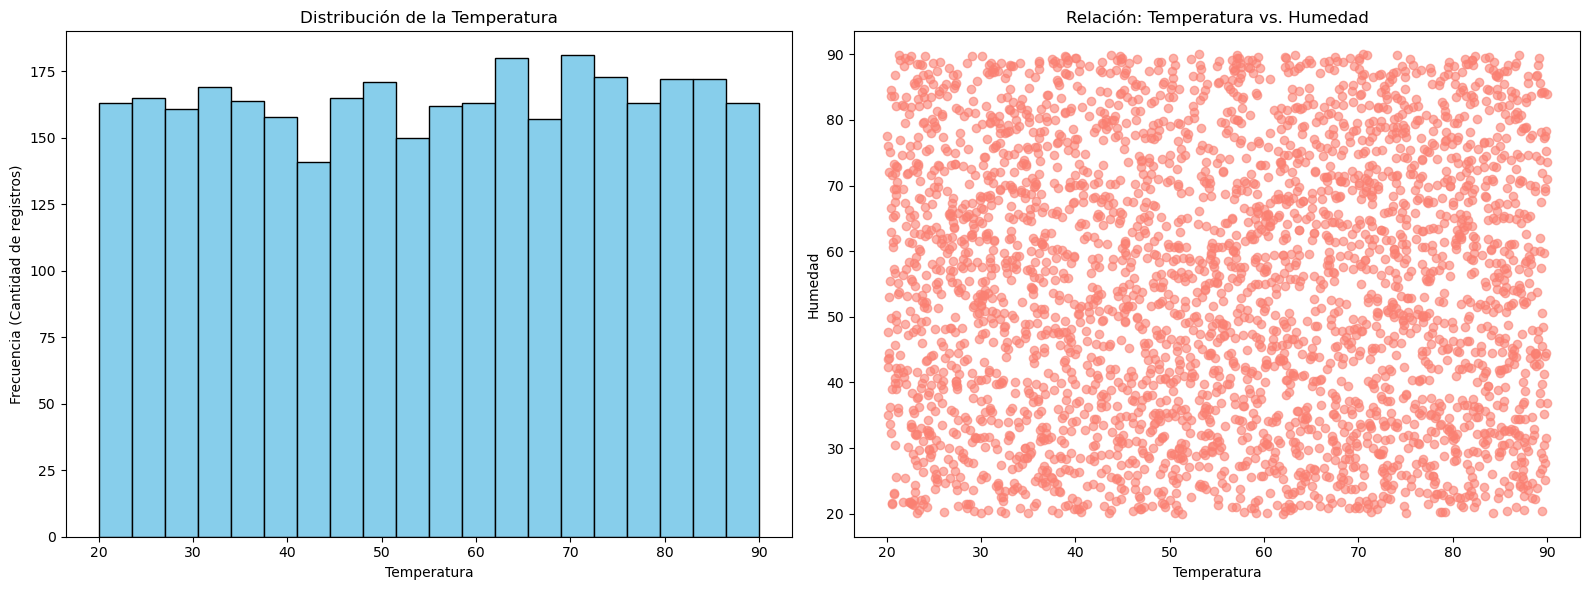

¡Gráficos generados correctamente!


In [25]:
# --- SOLUCIÓN EJERCICIO 11: GRAFICAR CON MATPLOTLIB ---
import matplotlib.pyplot as plt
import pandas as pd

# Esto es necesario para que los gráficos se vean dentro del notebook
%matplotlib inline

print("Convirtiendo datos de Spark a Pandas... (esto puede tardar un poco si hay muchos datos)")

# 1. CONVERTIR A PANDAS
# Traemos los datos de la "foto fija" (df_exploracion) a la memoria local.
pdf = df_exploracion.toPandas()

# 2. GENERAR LOS DOS GRÁFICOS
# Preparamos un "lienzo" grande para poner los dos gráficos lado a lado
plt.figure(figsize=(16, 6))

# --- Gráfico 1: Histograma de Temperatura ---
plt.subplot(1, 2, 1)  # (1 fila, 2 columnas, gráfico nº 1)
plt.hist(pdf["temperature"], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribución de la Temperatura")
plt.xlabel("Temperatura")
plt.ylabel("Frecuencia (Cantidad de registros)")

# --- Gráfico 2: Dispersión Temperatura vs Humedad ---
plt.subplot(1, 2, 2)  # (1 fila, 2 columnas, gráfico nº 2)
plt.scatter(pdf["temperature"], pdf["humidity"], color='salmon', alpha=0.6)
plt.title("Relación: Temperatura vs. Humedad")
plt.xlabel("Temperatura")
plt.ylabel("Humedad")

# Ajustamos el diseño y mostramos
plt.tight_layout()
plt.show()

print("¡Gráficos generados correctamente!")